In [52]:
import numpy as np
import matplotlib.pyplot as plt
import shutil
import numpy.random as rng

fontsi = 15
fontsi2 = 20
if shutil.which('latex') is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']
plt.rc('font', family='serif')
plt.rcParams.update({'font.size': fontsi})

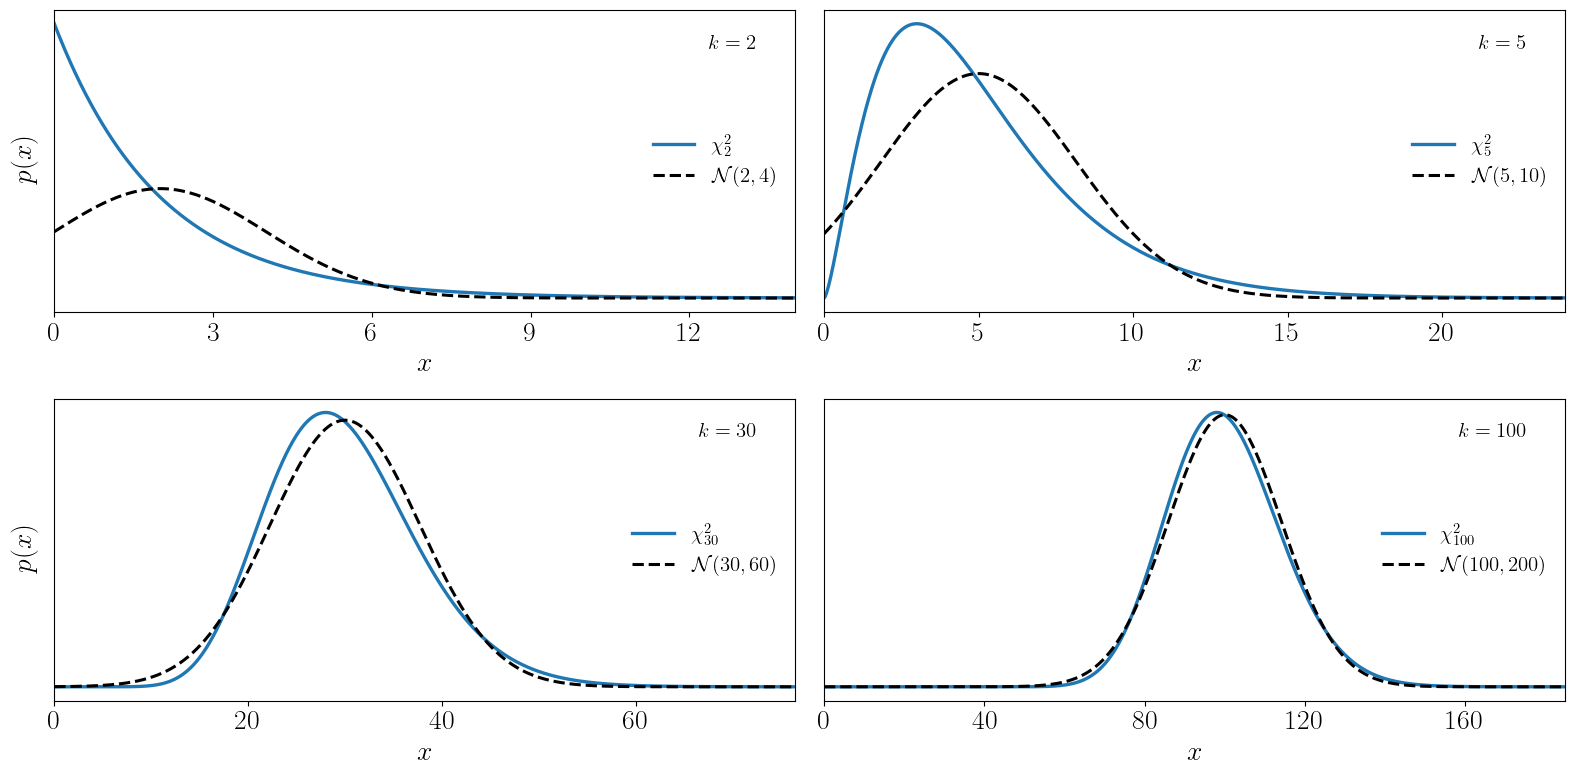

In [58]:
from math import gamma
from matplotlib.ticker import MaxNLocator


def chi2_pdf(x, k):
    # Chi-square PDF with k degrees of freedom.
    coef = 1.0 / (2.0 ** (k / 2.0) * gamma(k / 2.0))
    return coef * x ** (k / 2.0 - 1.0) * np.exp(-x / 2.0)


def gaussian_approx_pdf(x, k):
    # CLT approximation: chi^2_k ~ N(k, 2k) for large k.
    mu = k
    sigma = np.sqrt(2.0 * k)
    return (1.0 / (sigma * np.sqrt(2.0 * np.pi))) * np.exp(-((x - mu) ** 2) / (2.0 * sigma**2))


ks = [2, 5, 30, 100]
fig, axes = plt.subplots(2, 2, figsize=(16, 8.0), sharex=False, sharey=False)

for ax, k in zip(axes.flat, ks):
    xmax = max(12.0, k + 6 * np.sqrt(2.0 * k))
    x = np.linspace(1e-6, xmax, 1400)

    ax.plot(x, chi2_pdf(x, k), color='tab:blue', lw=2.4, label=rf"$\chi^2_{{{k}}}$")
    ax.plot(x, gaussian_approx_pdf(x, k), 'k--', lw=2.2, label=rf"$\mathcal{{N}}({k}, {2 * k})$")

    ax.text(
        0.95, 0.92, rf'$k={k}$',
        transform=ax.transAxes, ha='right', va='top', fontsize=fontsi,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='0.7', alpha=0.),
    )
    ax.set_xlabel(r'$x$', fontsize=fontsi2)
    ax.set_ylabel('')
    ax.set_yticks([])
    ax.tick_params(labelsize=fontsi2)
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.legend(fontsize=fontsi, frameon=False, loc='center right')
    ax.set_xlim(0.0, xmax)

axes[0, 0].set_ylabel(r'$p(x)$', fontsize=fontsi2, labelpad = 12)
axes[1, 0].set_ylabel(r'$p(x)$', fontsize=fontsi2, labelpad = 12)

fig.subplots_adjust(wspace=0.0, hspace=0.22)
plt.tight_layout()
plt.savefig('4_plots_chi2_to_gaussian.pdf')
plt.show()

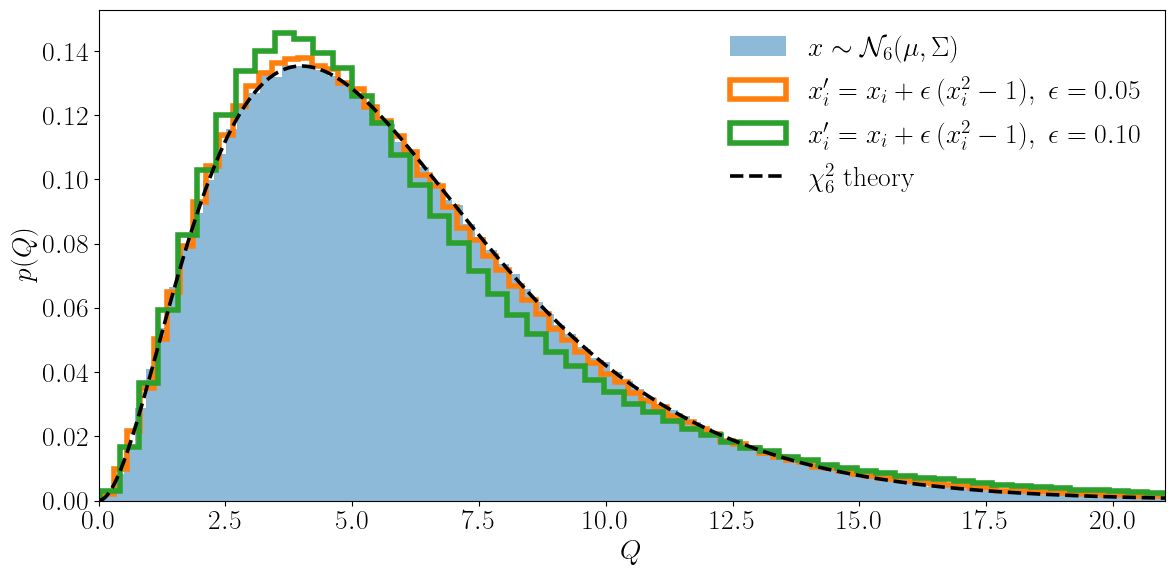

In [61]:
d = 6
mu = np.zeros(d)

# Positive-definite covariance with off-diagonal correlations.
Sigma = 0.6 ** np.abs(np.subtract.outer(np.arange(d), np.arange(d)))
Sigma_inv = np.linalg.inv(Sigma)

n_samples = 1_000_000
rng_engine = np.random.default_rng(7)
X = rng_engine.multivariate_normal(mean=mu, cov=Sigma, size=n_samples)

# Quadratic form Q = (x-mu)^T Sigma^{-1} (x-mu).
Q = np.einsum("ni,ij,nj->n", X - mu, Sigma_inv, X - mu)

# Small perturbation 1 only. Increase/decrease this to scale deviation strength.
perturb_strength = 0.05
X_skew = X + perturb_strength * (X**2 - 1.0)
Q_skew = np.einsum("ni,ij,nj->n", X_skew - mu, Sigma_inv, X_skew - mu)

xmax = np.percentile(np.concatenate([Q, Q_skew]), 99.7)
x = np.linspace(0.0, xmax, 900)

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    Q,
    bins=200,
    density=True,
    alpha = .5,
    linewidth=1.8,
    color='tab:blue',
    label=rf"$x\sim\mathcal{{N}}_{{{d}}}(\mu,\Sigma)$"
)
ax.hist(
    Q_skew,
    bins=200,
    density=True,
    histtype='step',
    linewidth=4,
    color='tab:orange',
    label=rf"$x_i' = x_i + \epsilon\,(x_i^2-1),\ \epsilon={perturb_strength:.2f}$"
)

perturb_strength = 0.1
X_skew = X + perturb_strength * (X**2 - 1.0)
Q_skew = np.einsum("ni,ij,nj->n", X_skew - mu, Sigma_inv, X_skew - mu)


ax.hist(
    Q_skew,
    bins=200,
    density=True,
    histtype='step',
    linewidth=4,
    color='tab:green',
    label=rf"$x_i' = x_i + \epsilon\,(x_i^2-1),\ \epsilon={perturb_strength:.2f}$"
)


ax.plot(x, chi2_pdf(x, d), color='k', lw=2.6, ls='--', label=rf'$\chi^2_{{{d}}}\;\mathrm{{theory}}$')

ax.set_xlabel(r'$Q$', fontsize=fontsi2)
ax.set_ylabel(r'$p(Q)$', fontsize=fontsi2)
ax.tick_params(labelsize=fontsi2)
ax.legend(fontsize=fontsi2, frameon=False, loc='upper right')
ax.set_xlim(0.0, xmax)
plt.tight_layout()
plt.savefig('4_plots_mvn_to_chi2_perturbations.pdf')
plt.show()

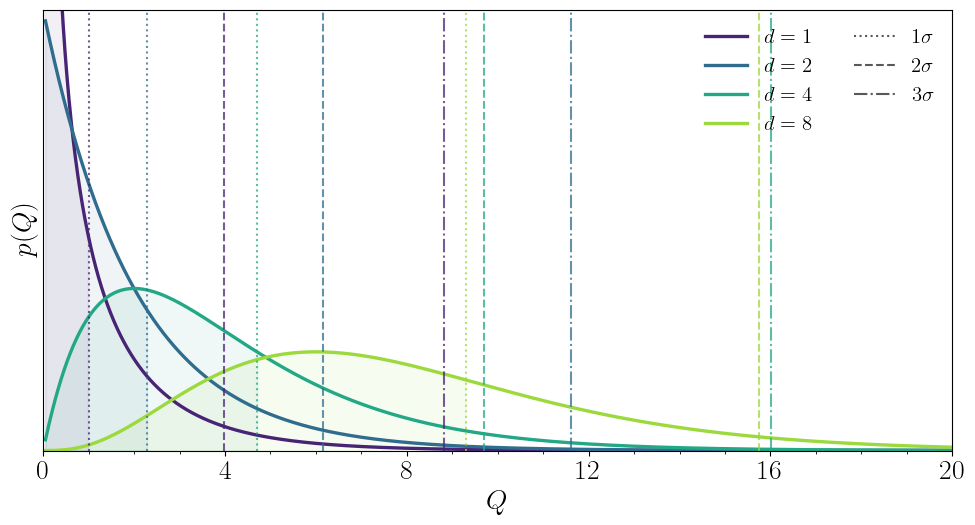

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import shutil
from scipy.stats import chi2
from matplotlib.ticker import MultipleLocator, MaxNLocator
from matplotlib.lines import Line2D

fontsi  = 15
fontsi2 = 20
if shutil.which('latex') is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']
plt.rc('font', family='serif')
plt.rcParams.update({'font.size': fontsi})

dofs      = [1, 2, 4, 8]
coverages = [0.682, 0.954, 0.997]
cov_labels = [r"$1\sigma$", r"$2\sigma$", r"$3\sigma$"]
cov_ls    = [":",  "--", "-."]
cmap   = plt.cm.viridis
colors = [cmap(v) for v in np.linspace(0.1, 0.85, len(dofs))]

xmax = 20
x    = np.linspace(0.05, xmax, 3000)

fig, ax = plt.subplots(figsize=(10, 5.5))

for d, col in zip(dofs, colors):
    pdf_vals = chi2.pdf(x, d)
    ax.plot(x, pdf_vals, lw=2.4, color=col)
    xc = chi2.ppf(coverages[0], d)
    mask = x <= xc
    ax.fill_between(x[mask], pdf_vals[mask], alpha=0.07, color=col)

for d, col in zip(dofs, colors):
    for p, ls in zip(coverages, cov_ls):
        xc = chi2.ppf(p, d)
        ax.axvline(xc, color=col, ls=ls, lw=1.5, alpha=0.75)

d_handles = [Line2D([0], [0], color=col, lw=2.4, label=rf"$d={d}$")
             for d, col in zip(dofs, colors)]
sig_handles = [Line2D([0], [0], color='0.35', ls=ls, lw=1.5, label=label)
               for ls, label in zip(cov_ls, cov_labels)]

ax.legend(handles=d_handles + sig_handles, fontsize=fontsi,
          frameon=False, ncol=2)

ax.set_xlabel(r"$Q$", fontsize=fontsi2)
ax.set_ylabel(r"$p(Q)$", fontsize=fontsi2)
ax.set_xlim(0, xmax)
ax.set_ylim(0, 0.5)
ax.tick_params(labelsize=fontsi2)
ax.set_yticks([])
ax.xaxis.set_major_locator(MaxNLocator(6))
ax.xaxis.set_minor_locator(MultipleLocator(1))

plt.tight_layout()
plt.savefig("4_plots_chi2_coverage.pdf")
plt.show()

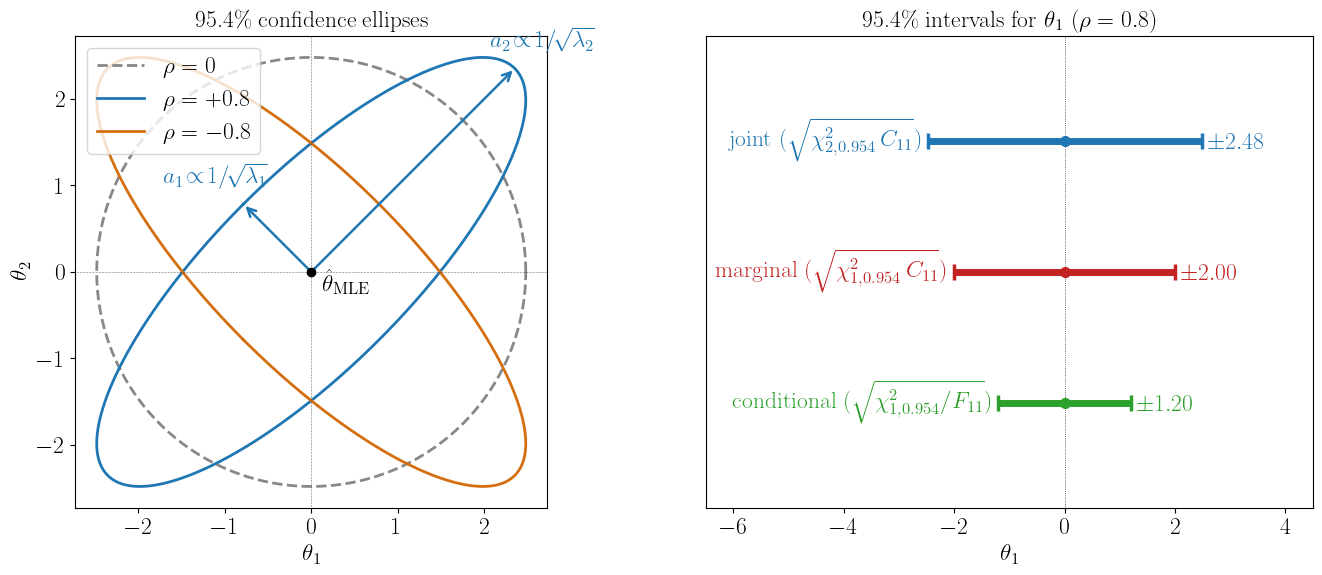

In [47]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

delta2 = chi2.ppf(0.954, df=2)   # 6.158
delta1 = chi2.ppf(0.954, df=1)   # 3.982

fontsi = 17
fontsi2 = 17

def cov_matrix(rho):
    return np.array([[1.0, rho], [rho, 1.0]])

def ellipse_points(C, delta, n=600):
    vals, vecs = np.linalg.eigh(C)
    t = np.linspace(0, 2*np.pi, n)
    axes_len = np.sqrt(delta * vals)
    pts = (vecs * axes_len) @ np.c_[np.cos(t), np.sin(t)].T
    return pts[0], pts[1]


fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 6))


rhos_l   = [0.0,    0.8,      -0.8]
colors_l = ['#888888', '#1f77b4', '#d46f10']
styles_l = ['--',   '-',       '-']
labels_l = [r'$\rho=0$', r'$\rho=+0.8$', r'$\rho=-0.8$']

for rho, col, ls, lab in zip(rhos_l, colors_l, styles_l, labels_l):
    ex, ey = ellipse_points(cov_matrix(rho), delta2)
    ax_l.plot(ex, ey, color=col, ls=ls, lw=2.0, label=lab)

# eigenvector arrows for ρ = +0.8
C08 = cov_matrix(0.8)

vals, vecs = np.linalg.eigh(C08)
arrow_kw = dict(arrowstyle='->', color='#1f77b4', lw=1.8,
                mutation_scale=14)
for i in range(2):
    ai  = np.sqrt(delta2 * vals[i])
    vec = vecs[:, i] * ai
    ax_l.annotate('', xy=vec, xytext=(0, 0),
                  arrowprops=dict(arrowstyle='->', color='#1f77b4', lw=1.8))
    off = vec / np.linalg.norm(vec) * 0.45
    ax_l.text(vec[0] + off[0], vec[1] + off[1],
              rf'$a_{i+1}\!\propto\!1/\!\sqrt{{\lambda_{i+1}}}$',
              color='#1f77b4', fontsize=fontsi , ha='center', va='center')

ax_l.plot(0, 0, 'ko', ms=6, zorder=5)
ax_l.text(0.12, -0.22, r'$\hat\theta_\mathrm{MLE}$', fontsize=fontsi)
ax_l.axhline(0, color='k', lw=0.4, ls=':')
ax_l.axvline(0, color='k', lw=0.4, ls=':')
ax_l.set_xlabel(r'$\theta_1$', fontsize=fontsi2)
ax_l.set_ylabel(r'$\theta_2$', fontsize=fontsi2)
ax_l.tick_params(labelsize=fontsi)
ax_l.set_aspect('equal')
ax_l.legend(fontsize=fontsi, frameon=True, loc='upper left')
ax_l.set_title(r'95.4\% confidence ellipses', fontsize=fontsi)


rho  = 0.8
C    = cov_matrix(rho)
Finv = C                       # Cov matrix (σ=1 Gaussian)
F    = np.linalg.inv(C)

hw_joint = np.sqrt(delta2 * Finv[0, 0])   # 2.481
hw_marg  = np.sqrt(delta1 * Finv[0, 0])   # 1.995
hw_cond  = np.sqrt(delta1 / F[0, 0])      # 1.197

intervals = [
    (hw_joint, '#1f77b4', r'joint  $(\sqrt{\chi^2_{2,0.954}\,C_{11}})$',    2.0),
    (hw_marg,  '#c42323', r'marginal  $(\sqrt{\chi^2_{1,0.954}\,C_{11}})$',  1.0),
    (hw_cond,  '#2ca02c', r'conditional  $(\sqrt{\chi^2_{1,0.954}/F_{11}})$',0.0),
]

for hw, col, lab, ypos in intervals:
    ax_r.plot([-hw, hw], [ypos, ypos], color=col, lw=5, solid_capstyle='butt',
              marker='|', ms=12, mew=2.5)
    ax_r.plot(0, ypos, 'o', color=col, ms=7, zorder=5)
    ax_r.text(hw + 0.12, ypos,  rf'$\pm{hw:.2f}$',
              va='center', color=col, fontsize=fontsi)
    ax_r.text(-hw - 0.12, ypos, lab,
              va='center', ha='right', color=col, fontsize=fontsi)

ax_r.axvline(0, color='k', lw=0.5, ls=':')
ax_r.set_xlabel(r'$\theta_1$', fontsize=fontsi2)
ax_r.set_yticks([])
ax_r.set_xlim(-6.5, 4.5)
ax_r.set_ylim(-0.8, 2.8)
ax_r.tick_params(labelsize=fontsi)
ax_r.set_title(r'95.4\% intervals for $\theta_1$ ($\rho=0.8$)', fontsize=fontsi)


plt.tight_layout()
plt.savefig('4_plots_confidence_ellipses.pdf', bbox_inches='tight')
plt.show()
